**Author**: Felipe Matheus  
**Start Date**: 02/07/2026  
**End Date**: /07/2026  
**Related Links**:

**Objective**

Build an uncertainty-aware probabilistic predictor of Grain size after the **annealing** process, using AutoGluon. The output of every prediction is a Gaussian-like predictive distribution $\mathcal{N}(\hat\mu, \hat\sigma^2)$ where the variance is decomposed into epistemic and aleatoric components.

**Pipeline**

1. Setup and global configuration.
2. Load + preprocess data.
3. Train **Model A** (mean predictor with internal K-fold bagging).
4. Extract OOF predictions per base learner.
5. Recover ensemble weights via NNLS; compute weighted $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$.
6. Build aleatoric targets $\tilde r^2 = \max(r^2_{\text{OOF}} - \hat\sigma^2_{\text{epist}}, 0)$.
7. Train **Model B** on $\log(\tilde r^2 + \epsilon)$.
8. Calibration diagnostics and scalar recalibration.

# 1. Setup

In [1]:
import os
import sys
import pickle

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from scipy.stats import norm
from autogluon.tabular import TabularPredictor


module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.processing.Processing import Processing
from src.feature_engineering.FeatureEngineering import FeatureEngineering
from src.modeling.Modeling import Modeling
from src.metrics.Evaluation import Evaluation
from src.DataLoader import LoaderHelper

from config.Variables import Variables

%load_ext autoreload
%autoreload 2

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Helper instances reused across the notebook.
proc = Processing()
feng = FeatureEngineering()
modl = Modeling()
evla = Evaluation()
varv = Variables()
load = LoaderHelper()


## 1.1 Global configuration

All knobs that may change between surrogates / processes / experiments live here. Other notebooks for other surrogates only need to edit this cell.

In [ ]:
# ---- Experiment settings ----
TAG = "first_test_old_data"
# SCHEMA_DATE = "080626"

# ---- Paths ----
FILE_NAME = "dataset_annealing_grain-size_new.csv"
# FILE_NAME_SCHEMA_DATA = "schema_annealing_essays_{}.csv".format(SCHEMA_DATE)
# FILE_NAME_VALIDATION_DATA = "Experimental Results Annealing V2 - CompiledResults.csv"

PROCESS = "annealing_grain_size"

# All artifacts of THIS run (predictors included) live under the TAG folder,
# so different experiments never overwrite each other's models.
EXPERIMENT_DIR = os.path.join(varv.PATHS.models, PROCESS, TAG)
os.makedirs(EXPERIMENT_DIR, exist_ok=True)

# ---- Dataset schema ----
TARGET = "grain_size_final"
FEATURES = ["purity", "grain_size", "temperature", "time"]
WEIGHT_ON_ESSAY_ROWS = 1

# ---- AutoGluon training knobs (Model A) ----
PRESETS_A = "medium_quality"     # 'best_quality' for final runs only or medium_quality
NUM_BAG_FOLDS_A = 5               # K-fold bagging produces OOF preds
NUM_BAG_SETS_A = 1
NUM_STACK_LEVELS_A = 0            # no multi-level stacking; keep simple
TIME_LIMIT_A = 120

# ---- AutoGluon training knobs (Model B) ----
PRESETS_B = "medium_quality"
NUM_BAG_FOLDS_B = 5
NUM_STACK_LEVELS_B = 0
TIME_LIMIT_B = 60

# ---- Uncertainty pipeline knobs ----
USE_WEIGHTED_VARIANCE = True      # False = uniform mean/var (sanity check); stay with True.
VARIANCE_FLOOR_FRAC = 0.01        # floor of sigma2_aleat as fraction of Var(y), in case of predictions as "100% sure" it still adds  small variance
CALIBRATION_ALPHAS = (0.5, 0.8, 0.9, 0.95)
RECALIBRATION_TARGET_ALPHA = 0.9

# ---- AGL x H2O comparison ----
USE_SHARED_FOLDS = False           # same fold_id column on both engines
FOLD_SEED = 42

# ---- Physical constraints (inference-time) ----
# Grain size is strictly positive and has NO physical ceiling (grain growth
# is unbounded on this scale): lower bound only, unlike the %IACS notebook.
Y_MIN = 0.0
Y_MAX = None


# 2. Data

## 2.1 Literature data

In [4]:
# Raw CSV.
df_raw = pd.read_csv(os.path.join(varv.PATHS.data_processed, FILE_NAME))
df_raw

,purity,time,temperature,grain_size,grain_size_final,grain_size_ratio
0,99.990,60.0,673.0,100.0,250.0,2.500000
1,99.990,60.0,773.0,100.0,300.0,3.000000
2,99.420,120.0,773.0,200.0,400.0,2.000000
3,99.900,60.0,673.0,100.0,350.0,3.500000
4,99.900,60.0,773.0,100.0,900.0,9.000000
...,...,...,...,...,...,...
108,99.960,30.0,453.0,4400.0,6600.0,1.500000
109,99.960,30.0,473.0,4400.0,7000.0,1.590909
110,99.960,30.0,523.0,4400.0,7800.0,1.772727
111,99.960,60.0,573.0,4400.0,11300.0,2.568182


In [ ]:
# Cast to float and keep the schema columns. Unlike the IACS/UTS datasets,
# this CSV has no "material"/"DOI" columns, so element labelling and ratio
# masks are skipped when absent (kept generic for future dataset versions).
df_float = proc.df_to_float(
    df_raw,
    drop_cols=[c for c in df_raw if c not in FEATURES + [TARGET]],
    # ignore_columns=[c for c in ("material",) if c in df_raw.columns],
)
df_float = df_float.drop_duplicates()

df_lit = df_float[FEATURES + [TARGET]].dropna(subset=[TARGET]).reset_index(drop=True)
df_lit["is_essay"] = False

assert df_lit[FEATURES + [TARGET]].isna().sum().sum() == 0, "NaNs in inputs"
assert "grain_size_ratio" not in df_lit.columns, "leakage column survived"
print(f"Dataset: {df_lit.shape}")
df_lit.head()


Dataset: (113, 6)


,purity,grain_size,temperature,time,grain_size_final,is_essay
0,99.99,100.0,673.0,60.0,250.0,False
1,99.99,100.0,773.0,60.0,300.0,False
2,99.42,200.0,773.0,120.0,400.0,False
3,99.90,100.0,673.0,60.0,350.0,False
4,99.90,100.0,773.0,60.0,900.0,False


## 2.3 Concat dataset

In [6]:
df = pd.concat([df_lit], ignore_index=True)

df["weight_col"] = np.where(df["is_essay"], WEIGHT_ON_ESSAY_ROWS, 1.0)

# Optional shared fold column: the SAME partition is passed to AutoGluon
# (groups=) and H2O (fold_column=) so OOF comparisons use identical folds.
if USE_SHARED_FOLDS:
    df = feng.add_stratified_fold_column(
        df, n_folds=NUM_BAG_FOLDS_A, seed=FOLD_SEED,
    )

df


,purity,grain_size,temperature,time,grain_size_final,is_essay,weight_col
0,99.990,100.0,673.0,60.0,250.0,False,1.0
1,99.990,100.0,773.0,60.0,300.0,False,1.0
2,99.420,200.0,773.0,120.0,400.0,False,1.0
3,99.900,100.0,673.0,60.0,350.0,False,1.0
4,99.900,100.0,773.0,60.0,900.0,False,1.0
...,...,...,...,...,...,...,...
108,99.960,4400.0,453.0,30.0,6600.0,False,1.0
109,99.960,4400.0,473.0,30.0,7000.0,False,1.0
110,99.960,4400.0,523.0,30.0,7800.0,False,1.0
111,99.960,4400.0,573.0,60.0,11300.0,False,1.0


## 2.4 Validation data

In [7]:
# # ---- Validation data ----
# # The Chimie Paris compiled results may not include measured final grain
# # sizes. Load defensively: if the TARGET column is absent, skip the
# # validation sections gracefully (df_val = None).
# try:
#     df_val = proc.load_validation_data_chimie_paris(
#         path=os.path.join(varv.PATHS.data_processed, FILE_NAME_VALIDATION_DATA)
#     )
#     if TARGET not in df_val.columns:
#         print(f"Validation file has no '{TARGET}' column -> df_val = None "
#               f"(sections 8.1/9 will be skipped).")
#         df_val = None
# except FileNotFoundError:
#     print("Validation file not found -> df_val = None.")
#     df_val = None


# 3. Train Model A — Mean Predictor with Bagging

Model A is an AutoGluon ensemble trained with $K$-fold bagging internally. Bagging is non-optional: without it we cannot extract OOF predictions, which are required for honest residuals and for the epistemic-variance estimate.

In [8]:
df.head(10)

,purity,grain_size,temperature,time,grain_size_final,is_essay,weight_col
0,99.99,100.0,673.0,60.0,250.0,False,1.0
1,99.99,100.0,773.0,60.0,300.0,False,1.0
2,99.42,200.0,773.0,120.0,400.0,False,1.0
3,99.90,100.0,673.0,60.0,350.0,False,1.0
4,99.90,100.0,773.0,60.0,900.0,False,1.0
5,99.90,100.0,673.0,60.0,300.0,False,1.0
6,99.90,100.0,773.0,60.0,800.0,False,1.0
7,99.90,100.0,673.0,60.0,450.0,False,1.0
8,99.55,300.0,648.0,90.0,482.0,False,1.0
9,99.98,320.0,573.0,120.0,1000.0,False,1.0


In [9]:
predictor_a = modl.fit_model_a(
    df=df,
    target=TARGET,
    features=FEATURES,
    path=os.path.join(EXPERIMENT_DIR, "model_a"),
    presets=PRESETS_A,
    num_bag_folds=NUM_BAG_FOLDS_A,
    num_bag_sets=NUM_BAG_SETS_A,
    num_stack_levels=NUM_STACK_LEVELS_A,
    time_limit=TIME_LIMIT_A,
    groups="fold_id" if USE_SHARED_FOLDS else None,
    sample_weight="weight_col",
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       9.38 GB / 31.57 GB (29.7%)
Disk Space Avail:   730.44 GB / 932.08 GB (78.4%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Values in column 'weight_col' used as sample weights instead of predictive features. Evaluation metrics will ignore sample weights, specify weight_evaluation=True to instead report weighted metrics.
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_grain_size\first_test_old_data\model_a"
Train Data Rows:    113
Train Data Columns: 5
Label Column:       grain_size_final
AutoGluon infers yo

In [10]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# base learners that feed into it.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-386.024259,root_mean_squared_error,0.094443,9.244621,0.000509,0.010178,2,True,10
1,RandomForestMSE_BAG_L1,-430.832616,root_mean_squared_error,0.030081,0.687842,0.030081,0.687842,1,True,3
2,XGBoost_BAG_L1,-451.516346,root_mean_squared_error,0.013543,1.046359,0.013543,1.046359,1,True,7
3,NeuralNetFastAI_BAG_L1,-497.052974,root_mean_squared_error,0.050310,7.500243,0.050310,7.500243,1,True,6
4,CatBoost_BAG_L1,-497.956744,root_mean_squared_error,0.016547,43.931687,0.016547,43.931687,1,True,4
5,ExtraTreesMSE_BAG_L1,-513.200650,root_mean_squared_error,0.039438,0.376759,0.039438,0.376759,1,True,5
6,LightGBMLarge_BAG_L1,-578.090986,root_mean_squared_error,0.010033,1.426739,0.010033,1.426739,1,True,9
7,NeuralNetTorch_BAG_L1,-758.480848,root_mean_squared_error,0.029083,14.766089,0.029083,14.766089,1,True,8
8,LightGBM_BAG_L1,-1596.920540,root_mean_squared_error,0.008310,0.673626,0.008310,0.673626,1,True,2
9,LightGBMXT_BAG_L1,-1623.822516,root_mean_squared_error,0.015778,0.989033,0.015778,0.989033,1,True,1


## 3.1 H2O AutoML Comparison

Quick H2O AutoML run with the same time budget and cross-validation folds as Model A, to benchmark AutoGluon's OOF RMSE against H2O's leader CV RMSE.

In [11]:
import h2o
from h2o.automl import H2OAutoML

h2o.init(nthreads=-1, max_mem_size="4G")

h2o_cols = FEATURES + [TARGET, "weight_col"]
if USE_SHARED_FOLDS:
    h2o_cols.append("fold_id")
train_h2o = h2o.H2OFrame(df[h2o_cols])
train_h2o[TARGET] = train_h2o[TARGET].asnumeric()
if USE_SHARED_FOLDS:
    # fold_column must be categorical on the H2O side.
    train_h2o["fold_id"] = train_h2o["fold_id"].asfactor()

aml_kwargs = dict(
    max_runtime_secs=TIME_LIMIT_A,
    keep_cross_validation_predictions=True,
    exclude_algos=["DeepLearning"],
    sort_metric="RMSE",
    seed=42,
)
if not USE_SHARED_FOLDS:
    aml_kwargs["nfolds"] = NUM_BAG_FOLDS_A  # nfolds is ignored/conflicting with fold_column

aml_h2o = H2OAutoML(**aml_kwargs)

train_kwargs = dict(x=FEATURES, y=TARGET, training_frame=train_h2o,
                    weights_column="weight_col")
if USE_SHARED_FOLDS:
    train_kwargs["fold_column"] = "fold_id"

aml_h2o.train(**train_kwargs)

aml_h2o.leaderboard.head(10)


Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 24.0.2+12-54, mixed mode, sharing)
  Starting server from C:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\fmfoa\AppData\Local\Temp\tmpxq1mtl4s
  JVM stdout: C:\Users\fmfoa\AppData\Local\Temp\tmpxq1mtl4s\h2o_fmfoa_started_from_python.out
  JVM stderr: C:\Users\fmfoa\AppData\Local\Temp\tmpxq1mtl4s\h2o_fmfoa_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Europe/Paris
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,4 months and 1 day
H2O_cluster_name:,H2O_from_python_fmfoa_fjphba
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.983 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
14:33:04.833: AutoML: XGBoost is not available; skipping it.


14:33:05.193: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 113.0.

██
14:33:06.432: _weights_column param, All base models use weights_column="weight_col" but Stacked Ensemble does not. If you want to use the same weights_column for the meta learner, please specify it as an argument in the h2o.stackedEnsemble call.
14:33:06.563: _weights_column param, All base models use weights_column="weight_col" but Stacked Ensemble does not. If you want to use the same weights_column for the meta learner, please specify it as an argument in the h2o.stackedEnsemble call.

██
14:33:07.64: _weights_column param, All base models use weights_column="weight_col" but Stacked Ensemble does not. If you want to use the same weights_column for the me

model_id,rmse,mse,mae,rmsle,mean_residual_deviance
GBM_grid_1_AutoML_1_20260713_143304_model_519,355.826,126612,185.842,0.238811,126612
GBM_grid_1_AutoML_1_20260713_143304_model_565,362.775,131606,199.902,0.267661,131606
GBM_grid_1_AutoML_1_20260713_143304_model_728,363.78,132336,201.816,0.263957,132336
GBM_grid_1_AutoML_1_20260713_143304_model_206,365.844,133842,196.759,0.25818,133842
GBM_grid_1_AutoML_1_20260713_143304_model_31,366.088,134020,201.347,0.269899,134020
GBM_grid_1_AutoML_1_20260713_143304_model_191,366.762,134515,205.15,0.287454,134515
StackedEnsemble_BestOfFamily_3_AutoML_1_20260713_143304,369.823,136769,190.831,0.241426,136769
GBM_grid_1_AutoML_1_20260713_143304_model_600,374.4,140175,206.521,0.27411,140175
GBM_grid_1_AutoML_1_20260713_143304_model_177,376.151,141490,212.679,0.29616,141490
GBM_grid_1_AutoML_1_20260713_143304_model_725,377.931,142832,195.345,0.262954,142832


# 4. OOF Predictions and Ensemble Weights

Three things are needed before we can compute the epistemic variance:

1. The OOF predictions of the **final ensemble** (one value per row of the train set).
2. The OOF predictions of **each base learner** (one matrix `M × N`).
3. The **weights** that the WeightedEnsemble assigns to each base learner — recovered via NNLS from the OOF matrix and the ensemble OOF vector. The internal AutoGluon API for weights is not stable across versions; NNLS gives a robust route.

In [17]:
# OOF mean predictions of the final ensemble.
mu_oof = predictor_a.predict_oof()                  # pd.Series, index == df.index
residuals_oof = df[TARGET] - mu_oof
print(f"mu_oof: shape={mu_oof.shape}  any NaN? {mu_oof.isna().any()}")

mu_oof: shape=(113,)  any NaN? False


In [46]:
mu_oof

0       405.012360
1       841.531982
2       588.953613
3       383.468781
4       698.495544
          ...     
108    6474.777832
109    7014.717773
110    8632.258789
111    9815.884766
112     708.515442
Name: grain_size_final, Length: 113, dtype: float32

In [23]:
residuals_oof

0      -155.012360
1      -541.531982
2      -188.953613
3       -33.468781
4       201.504456
          ...     
108     125.222168
109     -14.717773
110    -832.258789
111    1484.115234
112    -208.515442
Name: grain_size_final, Length: 113, dtype: float64

In [24]:
df[residuals_oof.abs() > 1.5*residuals_oof.std()]

,purity,grain_size,temperature,time,grain_size_final,is_essay,weight_col
10,99.980,320.0,623.0,30.0,2000.0,False,1.0
16,99.980,320.0,473.0,30.0,500.0,False,1.0
91,99.900,500.0,673.0,2.0,4000.0,False,1.0
92,99.999,600.0,323.0,60.0,800.0,False,1.0
95,99.999,600.0,398.0,60.0,3000.0,False,1.0
98,99.999,450.0,398.0,60.0,2000.0,False,1.0
103,99.950,5000.0,473.0,60.0,7000.0,False,1.0
105,99.950,5000.0,548.0,60.0,11000.0,False,1.0
106,99.950,5000.0,573.0,60.0,12000.0,False,1.0
107,99.960,4400.0,438.0,30.0,5800.0,False,1.0


## 4.2 Recovering weights 

In [25]:
# OOF matrix per base learner (excludes WeightedEnsemble itself).
oof_matrix, base_model_names = modl.collect_oof_base_learners(predictor_a)
print(f"oof_matrix shape: {oof_matrix.shape}  (M base learners, N rows)")
print("Base learners:", base_model_names)

oof_matrix shape: (9, 113)  (M base learners, N rows)
Base learners: ['LightGBMXT_BAG_L1', 'LightGBM_BAG_L1', 'RandomForestMSE_BAG_L1', 'CatBoost_BAG_L1', 'ExtraTreesMSE_BAG_L1', 'NeuralNetFastAI_BAG_L1', 'XGBoost_BAG_L1', 'NeuralNetTorch_BAG_L1', 'LightGBMLarge_BAG_L1']


In [26]:
# Recover ensemble weights by solving (oof_matrix.T @ w = mu_oof) with w >= 0.
weights, is_recovery_ok, max_diff = modl.recover_ensemble_weights(
    oof_matrix=oof_matrix,
    mu_oof_ensemble=mu_oof.values,
)

print(f"Recovery max diff: {max_diff:.6f}  ({'OK' if is_recovery_ok else 'FALLBACK'})")
print("\nNon-zero weights:")
for name, w in zip(base_model_names, weights):
    if w > 1e-4:
        print(f"  {name:30s}  {w:.4f}")

Recovery max diff: 0.000389  (OK)

Non-zero weights:
  RandomForestMSE_BAG_L1          0.2400
  NeuralNetFastAI_BAG_L1          0.3200
  XGBoost_BAG_L1                  0.4400


# 5. Compute $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$

Following the law of total variance, the epistemic component is the spread of the predictions across base learners, weighted by the ensemble weights. The `USE_WEIGHTED_VARIANCE` flag toggles between weighted (the project default) and uniform statistics — the latter is useful as a robustness check, since it does not rely on the NNLS recovery.

In [27]:
mu_recomputed, sigma2_epist_oof = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=USE_WEIGHTED_VARIANCE,
)

mu_diffs = np.abs(mu_recomputed - mu_oof)
mu_diffs.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof):.4f}")
# print(f"  max    = {sigma2_epist_oof.max():.4f}")

count    1.130000e+02
mean     3.296836e-05
std      5.585406e-05
min      8.794309e-07
25%      7.931209e-06
50%      1.655319e-05
75%      2.888912e-05
max      3.886710e-04
Name: grain_size_final, dtype: float64

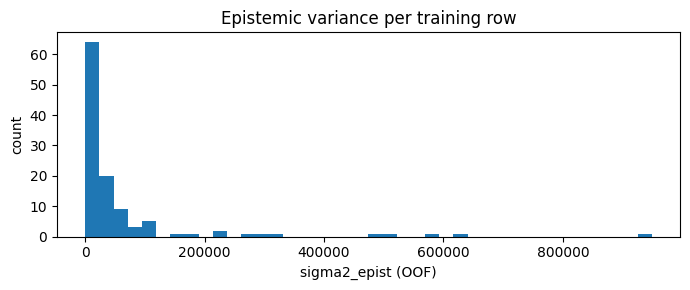

In [28]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Assesment comparing with lin

In [29]:
mu_recomputed_lin, sigma2_epist_oof_lin = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=False,
)

mu_diffs_lin = np.abs(mu_recomputed_lin - mu_oof)
mu_diffs_lin.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof_lin.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof_lin):.4f}")
# print(f"  max    = {sigma2_epist_oof_lin.max():.4f}")

count     113.000000
mean      210.486191
std       295.533264
min         4.800812
25%        49.664825
50%       108.810669
75%       221.010620
max      2048.342285
Name: grain_size_final, dtype: float64

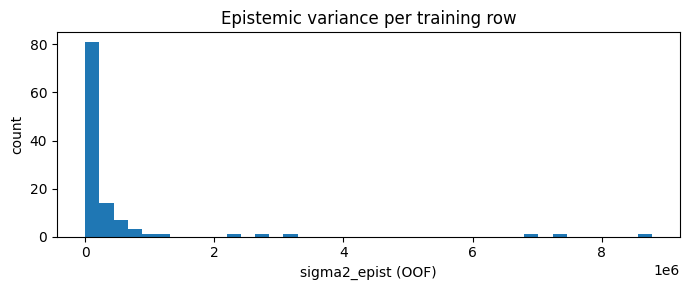

In [30]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof_lin, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Section 5 Conclusion

As expected on this big variance dataset, the variance is huge

# 6. Build Aleatoric Targets $\tilde r^2$

Each training row gets a noisy point-estimate of the aleatoric variance:

$$\tilde r_i^2 = \max\!\left((y_i - \hat\mu^{\text{OOF}}(\mathbf{x}_i))^2 - \hat\sigma^2_{\text{epist}}(\mathbf{x}_i),\;0\right).$$

Subtracting the epistemic component avoids double-counting it. Truncation at zero handles rows where the ensemble disagreement exceeds the squared residual.

In [31]:
r_tilde_sq, residuals_oof_arr, diag = modl.build_aleatoric_targets(
    y_true=df[TARGET].values,
    mu_oof=mu_oof.values,
    sigma2_epist_oof=sigma2_epist_oof,
)

print("=== Aleatoric target diagnostics ===")
for k, v in diag.items():
    print(f"  {k:20s} = {v}")

=== Aleatoric target diagnostics ===
  n_total              = 113
  n_truncated          = 64
  pct_truncated        = 56.63716814159292
  r_tilde_sq_min       = 0.0
  r_tilde_sq_max       = 2559757.3936551944
  r_tilde_sq_mean      = 120258.62144970236
  r_tilde_sq_median    = 0.0


In [32]:
r_tilde_sq

array([2.17969820e+04, 2.89302237e+05, 3.02211144e+04, 0.00000000e+00,
       3.07401113e+04, 4.96448882e+04, 0.00000000e+00, 0.00000000e+00,
       1.50097649e+05, 0.00000000e+00, 1.31507075e+06, 0.00000000e+00,
       1.34471001e+05, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       1.32368784e+05, 0.00000000e+00, 0.00000000e+00, 7.33279758e+04,
       0.00000000e+00, 0.00000000e+00, 3.75083142e+04, 0.00000000e+00,
       3.07245990e+02, 0.00000000e+00, 1.07352805e+03, 8.38883436e+03,
       4.26606993e+04, 7.56212836e+04, 2.58326353e+04, 7.86611997e+04,
       1.17552484e+04, 1.74778800e+03, 2.32573020e+04, 0.00000000e+00,
       2.74095892e+04, 0.00000000e+00, 0.00000000e+00, 1.22827211e+05,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       4.78571625e+03, 0.00000000e+00, 8.30651897e+01, 0.00000000e+00,
       8.01073687e+03, 5.96458130e+03, 4.89871326e+03, 1.14872659e+03,
       1.75931369e+01, 0.00000000e+00, 1.36699785e+03, 4.55482488e+03,
      

# 7. Train Model B — Aleatoric Variance Predictor

Model B is trained on $\log(\tilde r^2 + \epsilon)$ to keep the regression target well-conditioned (variances are non-negative and right-skewed). Inference back-transforms via $\exp$.

In [33]:
predictor_b = modl.fit_model_b(
    df=df,
    features=FEATURES,
    r_tilde_sq=r_tilde_sq,
    path=os.path.join(EXPERIMENT_DIR, "model_b"),
    presets=PRESETS_B,
    num_bag_folds=NUM_BAG_FOLDS_B,
    num_stack_levels=NUM_STACK_LEVELS_B,
    time_limit=TIME_LIMIT_B,
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       7.78 GB / 31.57 GB (24.6%)
Disk Space Avail:   729.95 GB / 932.08 GB (78.3%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_grain_size\first_test_old_data\model_b"
Train Data Rows:    113
Train Data Columns: 4
Label Column:       log_r_tilde_sq
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (14.755423043861915, -13.815510557964274, -3.

In [34]:
predictor_b.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-11.548308,root_mean_squared_error,0.079821,17.533149,0.000000,0.011560,2,True,10
1,NeuralNetFastAI_BAG_L1,-11.615513,root_mean_squared_error,0.039113,8.105122,0.039113,8.105122,1,True,6
2,CatBoost_BAG_L1,-11.834012,root_mean_squared_error,0.007529,9.114236,0.007529,9.114236,1,True,4
3,LightGBM_BAG_L1,-11.908200,root_mean_squared_error,0.002997,0.953754,0.002997,0.953754,1,True,2
4,LightGBMXT_BAG_L1,-11.917783,root_mean_squared_error,0.005016,1.096661,0.005016,1.096661,1,True,1
5,NeuralNetTorch_BAG_L1,-12.241361,root_mean_squared_error,0.030618,7.448151,0.030618,7.448151,1,True,8
6,LightGBMLarge_BAG_L1,-12.259983,root_mean_squared_error,0.003015,1.261987,0.003015,1.261987,1,True,9
7,XGBoost_BAG_L1,-12.284419,root_mean_squared_error,0.015054,1.093246,0.015054,1.093246,1,True,7
8,ExtraTreesMSE_BAG_L1,-12.887978,root_mean_squared_error,0.033180,0.302231,0.033180,0.302231,1,True,5
9,RandomForestMSE_BAG_L1,-13.313764,root_mean_squared_error,0.047431,0.428822,0.047431,0.428822,1,True,3


In [43]:
predictor_b.predict_oof()  

0     -0.948275
1     -1.703372
2     -1.872849
3     -1.096964
4     -2.558207
         ...   
108    0.100734
109    0.100469
110   -0.426414
111    4.788945
112   -4.679419
Name: log_r_tilde_sq, Length: 113, dtype: float32

In [47]:
df_lado_a_lado = pd.DataFrame({
    "residual_oof": residuals_oof,
    "predict_random_error": predictor_b.predict_oof(),
    "epistemic_error": sigma2_epist_oof,
    "grain_size": df["grain_size"],
    "grain_size_final": df[TARGET],
    "prediction":mu_oof
})
df_lado_a_lado


,residual_oof,predict_random_error,epistemic_error,grain_size,grain_size_final,prediction
0,-155.012360,-0.948275,2231.849643,100.0,250.0,405.012360
1,-541.531982,-1.703372,3954.650817,100.0,300.0,841.531982
2,-188.953613,-1.872849,5482.353594,200.0,400.0,588.953613
3,-33.468781,-1.096964,10314.619674,100.0,350.0,383.468781
4,201.504456,-2.558207,9863.934294,100.0,900.0,698.495544
...,...,...,...,...,...,...
108,125.222168,0.100734,570323.916607,4400.0,6600.0,6474.777832
109,-14.717773,0.100469,213892.763275,4400.0,7000.0,7014.717773
110,-832.258789,-0.426414,310627.324664,4400.0,7800.0,8632.258789
111,1484.115234,4.788945,306766.275618,4400.0,11300.0,9815.884766


# 8. Calibration Diagnostics

Test whether the central α-intervals produced by the predictive Gaussian actually contain the true $y$ on a fraction $\approx \alpha$ of OOF points.

- $\alpha$ here is the **nominal coverage** of an interval (between 0 and 1).
- Empirical coverage **below** nominal ⇒ overconfident (intervals too narrow).
- Empirical coverage **above** nominal ⇒ underconfident (intervals too wide).
- A scalar correction $\hat\sigma \mapsto c \cdot \hat\sigma$ pulls the worst level to nominal; we fit $c$ at $\alpha = 0.9$.

In [37]:
df[TARGET].var()

np.float64(5371838.7680151705)

Real coverage considering sigmas calculated so far

Build the predictive distribution. Not totally OOF cause model b is not generating OOF preds, we assume it's optimistic just a bit too small to be considered.


In [48]:
variance_floor = VARIANCE_FLOOR_FRAC * df[TARGET].var()
sigma2_aleat_oof = modl.predict_aleatoric_variance(
    predictor_b, df[FEATURES], variance_floor=variance_floor,
)

sigma2_total_oof = sigma2_epist_oof + sigma2_aleat_oof
sigma_total_oof = np.sqrt(sigma2_total_oof)

y_true = df[TARGET].values
cal_before = modl.calibration_table(
    mu=mu_oof.values, sigma=sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("=== Calibration BEFORE recalibration ===")
cal_before

=== Calibration BEFORE recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.707965,0.207965
1,0.80,0.867257,0.067257
2,0.90,0.920354,0.020354
3,0.95,0.920354,-0.029646


Fit a scalar recalibration factor to pull coverage using α=0.9 as nominal reference


In [49]:
c_opt = modl.fit_recalibration_scalar(
    mu=mu_oof.values,
    sigma=sigma_total_oof,
    y_true=y_true,
    target_alpha=RECALIBRATION_TARGET_ALPHA,
)
print(f"Recalibration scalar c = {c_opt:.4f}")

cal_after = modl.calibration_table(
    mu=mu_oof.values, sigma=c_opt * sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("\n=== Calibration AFTER recalibration ===")
cal_after

Recalibration scalar c = 0.8528

=== Calibration AFTER recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.654867,0.154867
1,0.80,0.823009,0.023009
2,0.90,0.893805,-0.006195
3,0.95,0.920354,-0.029646


# 8.1 Validation Set Evaluation

Evaluate the freshly trained pair (A + B, with the recalibration $c$) on a
validation DataFrame.

`modl.predict_target` is target-agnostic: it accepts a DataFrame **or a dict**
and any AutoGluon predictor (IACS, UTS, Model B...), inferring the features
from the predictor when not given.

In [56]:
df_val = df.sample(20)
df_val

,purity,grain_size,temperature,time,grain_size_final,is_essay,weight_col
109,99.960,4400.0,473.0,30.0,7000.0,False,1.0
102,99.999,250.0,398.0,60.0,600.0,False,1.0
12,99.980,320.0,523.0,60.0,360.0,False,1.0
55,99.900,180.0,673.0,60.0,550.0,False,1.0
107,99.960,4400.0,438.0,30.0,5800.0,False,1.0
71,99.900,140.0,723.0,60.0,580.0,False,1.0
57,99.900,220.0,573.0,60.0,470.0,False,1.0
50,99.900,200.0,473.0,60.0,350.0,False,1.0
17,99.980,320.0,573.0,120.0,900.0,False,1.0
39,99.700,120.0,573.0,60.0,900.0,False,1.0


In [60]:
print(type(Y_MIN), Y_MIN)
print(type(Y_MAX), Y_MAX)

<class 'float'> 0.0
<class 'NoneType'> None


In [64]:
# ---- Validation set evaluation (skipped when df_val is None) ----
if df_val is None:
    print("df_val is None -> skipping validation-set evaluation.")
else:
    preds_val = modl.predict_with_uncertainty(
        X=df_val.drop(columns=[TARGET, "weight_col", "is_essay"]),
        predictor_a=predictor_a,
        predictor_b=predictor_b,
        weights=weights,
        model_names=base_model_names,
        features=FEATURES,
        variance_floor=variance_floor,
        recalibration_c=c_opt,
        use_weights=USE_WEIGHTED_VARIANCE,
        # y_min=Y_MIN,
        # y_max=Y_MAX,
    )

    val_metrics = evla.metrics_on_dataframe(
        df=df_val.drop(columns=["weight_col", "is_essay"]),
        target=TARGET,
        mu=preds_val["mu"].to_numpy(),
        sigma=preds_val["sigma_total"].to_numpy(),
        alphas=CALIBRATION_ALPHAS,
    )
    print("=== Validation metrics ===")
    print({k: round(v, 4) for k, v in val_metrics.items() if k != "coverage"})
    print("coverage:", {a: round(c, 3) for a, c in val_metrics["coverage"].items()})


=== Validation metrics ===
{'rmse': 196.8947, 'mae': 137.1398, 'mape': 17.4083, 'r2': 0.9877}
coverage: {0.5: 0.75, 0.8: 0.95, 0.9: 0.95, 0.95: 0.95}


In [ ]:
val_metrics

{'rmse': 0.6634712232411377,
 'mae': 0.5638755623005847,
 'mape': 0.5589753556071076,
 'r2': -0.9904273395407273,
 'coverage': {0.5: 1.0, 0.8: 1.0, 0.9: 1.0, 0.95: 1.0}}

In [ ]:
df_val

,id,purity,initial_diameter,iacs,temperature,time,iacs_final
0,C1_250_30m_T1,99.95,1.2,98.47,523,30,101.08
1,C1_250_30m_T3,99.95,1.2,98.47,523,30,101.08
2,C1_250_60m_T1,99.95,1.2,98.47,523,60,100.82
3,C1_250_60m_T2,99.95,1.2,98.47,523,60,100.82
4,C1_250_90m_T1,99.95,1.2,98.47,523,90,101.22
5,C1_250_90m_T2,99.95,1.2,98.47,523,90,101.22
6,C1_250_30m_AQ_T1,99.95,1.2,98.47,523,30,100.95
7,C1_250_30m_AQ_T2,99.95,1.2,98.47,523,30,100.95
8,C1_300_30m_T1,99.95,1.2,98.47,573,30,102.03
9,C1_300_30m_T2,99.95,1.2,98.47,573,30,102.03


In [ ]:
preds_val

,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,100.607731,0.154607,1.411706,2.436095,1.560800,100.607727,1.0,100.595827,1.543914,0.002446
1,100.607731,0.154607,1.411706,2.436095,1.560800,100.607727,1.0,100.595827,1.543914,0.002446
2,100.614161,0.304952,1.411706,2.669927,1.633991,100.614159,1.0,100.596325,1.609777,0.003636
3,100.614161,0.304952,1.411706,2.669927,1.633991,100.614159,1.0,100.596325,1.609777,0.003636
4,99.853588,1.404557,1.411706,4.380150,2.092881,99.853584,1.0,99.812694,2.041573,0.006966
5,99.853588,1.404557,1.411706,4.380150,2.092881,99.853584,1.0,99.812694,2.041573,0.006966
6,100.607731,0.154607,1.411706,2.436095,1.560800,100.607727,1.0,100.595827,1.543914,0.002446
7,100.607731,0.154607,1.411706,2.436095,1.560800,100.607727,1.0,100.595827,1.543914,0.002446
8,101.368072,0.232564,1.411706,2.557342,1.599169,101.368073,1.0,101.319116,1.541799,0.011569
9,101.368072,0.232564,1.411706,2.557342,1.599169,101.368073,1.0,101.319116,1.541799,0.011569


In [ ]:
# ---- Target-agnostic point prediction from a plain dict ----
single = modl.predict_target(
    predictor_a,
    {"purity": 99.9, "grain_size": 100.0, "temperature": 623.0, "time": 60.0},
)
print(f"Predicted {TARGET}: {single[0]:.3f}")


# 9. Inference Example

Use the packaged `predict_with_uncertainty` to apply both models to new rows and return a full predictive distribution. The `recalibration_c` argument scales $\hat\sigma$ to match the calibration above.

In [ ]:
df.head(5)

,purity,iacs,temperature,time,iacs_final,is_essay,weight_col,fold_id
0,99.9,88.260,623.0,30.0,88.350,True,1.0,3
1,99.9,88.260,623.0,60.0,88.655,True,1.0,0
2,99.9,88.260,623.0,90.0,88.800,True,1.0,2
3,99.9,99.825,573.0,30.0,102.340,True,1.0,0
4,99.9,99.390,573.0,30.0,102.230,True,1.0,4


In [ ]:
# Fit the OOD reference on the training inputs (stored in artifacts later).
ood_ref = modl.fit_ood_reference(df, features=FEATURES)

preds = modl.predict_with_uncertainty(
    X=(df_val.head(5) if df_val is not None else df[FEATURES].head(5)),
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_min=Y_MIN,          # grain size > 0 -> truncated-Gaussian lower bound
    y_max=Y_MAX,
    ood_ref=ood_ref,      # inputs outside training cloud get inflated sigma
)
preds


# 10. Persist Artifacts

Save everything that the downstream stages (controller, propagation) will need.

In [ ]:
# ---- Experiment artifacts (everything under EXPERIMENT_DIR / TAG) ----
artifacts_path = os.path.join(EXPERIMENT_DIR, "artifacts.pkl")

artifacts = {
    "features": FEATURES,
    "target": TARGET,
    "base_model_names": base_model_names,
    "weights": weights,
    "variance_floor": variance_floor,
    "recalibration_c": c_opt,
    "use_weighted_variance": USE_WEIGHTED_VARIANCE,
    "calibration_before": cal_before,
    "calibration_after": cal_after,
    "y_min": Y_MIN,
    "y_max": Y_MAX,
    "ood_ref": ood_ref,
}
with open(artifacts_path, "wb") as f:
    pickle.dump(artifacts, f)

print(f"Saved to: {artifacts_path}")


In [ ]:
# ---- Save global configuration (1.1) as YAML for this experiment (TAG) ----
global_config = {
    "TAG": TAG,
    "SCHEMA_DATE": SCHEMA_DATE,
    "varv.PATHS.data_raw": varv.PATHS.data_raw,
    "varv.PATHS.models": varv.PATHS.models,
    "FILE_NAME": FILE_NAME,
    "FILE_NAME_SCHEMA_DATA": FILE_NAME_SCHEMA_DATA,
    "PROCESS": PROCESS,
    "TARGET": TARGET,
    "FEATURES": FEATURES,
    "WEIGHT_ON_ESSAY_ROWS": WEIGHT_ON_ESSAY_ROWS,
    "PRESETS_A": PRESETS_A,
    "NUM_BAG_FOLDS_A": NUM_BAG_FOLDS_A,
    "NUM_BAG_SETS_A": NUM_BAG_SETS_A,
    "NUM_STACK_LEVELS_A": NUM_STACK_LEVELS_A,
    "TIME_LIMIT_A": TIME_LIMIT_A,
    "PRESETS_B": PRESETS_B,
    "NUM_BAG_FOLDS_B": NUM_BAG_FOLDS_B,
    "NUM_STACK_LEVELS_B": NUM_STACK_LEVELS_B,
    "TIME_LIMIT_B": TIME_LIMIT_B,
    "USE_WEIGHTED_VARIANCE": USE_WEIGHTED_VARIANCE,
    "VARIANCE_FLOOR_FRAC": VARIANCE_FLOOR_FRAC,
    "CALIBRATION_ALPHAS": list(CALIBRATION_ALPHAS),
    "RECALIBRATION_TARGET_ALPHA": RECALIBRATION_TARGET_ALPHA,
    "USE_SHARED_FOLDS": USE_SHARED_FOLDS,
    "FOLD_SEED": FOLD_SEED,
    "Y_MIN": Y_MIN,
    "Y_MAX": Y_MAX,
}

config_path = os.path.join(EXPERIMENT_DIR, "global_config.txt")
with open(config_path, "w") as f:
    yaml.dump(global_config, f, default_flow_style=False, sort_keys=False)

print(f"Saved to: {config_path}")


In [ ]:
# ---- OOF metrics: AutoGluon (Model A leader) vs H2O AutoML leader ----
# Both vectors are out-of-fold predictions; metrics are UNWEIGHTED on both
# sides, and with USE_SHARED_FOLDS=True the folds are identical -> coherent.
h2o_oof_preds = (
    aml_h2o.leader.cross_validation_holdout_predictions()
    .as_data_frame()
    .iloc[:, 0]
    .to_numpy()
)

metrics_agl = evla.one_step_metrics(y_true=y_true, mu=mu_oof.values)
metrics_h2o = evla.one_step_metrics(y_true=y_true, mu=h2o_oof_preds)

metrics_df = pd.DataFrame(
    [
        {"model": "AutoGluon (Model A, leader)", **metrics_agl},
        {"model": "H2O AutoML (leader)", **metrics_h2o},
    ]
)[["model", "rmse", "mae", "mape", "r2"]]

print(metrics_df)

# ---- Leaderboards from both engines ----
leaderboard_agl = predictor_a.leaderboard(silent=True)
leaderboard_h2o = aml_h2o.leaderboard.as_data_frame()

# ---- Save everything for this experiment (TAG) into separate CSV files ----
metrics_df.to_csv(os.path.join(EXPERIMENT_DIR, "metrics_comparison.csv"), index=False)
leaderboard_agl.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_autogluon.csv"), index=False)
leaderboard_h2o.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_h2o.csv"), index=False)

print(f"Saved to: {EXPERIMENT_DIR}")


                         model      rmse       mae      mape        r2
0  AutoGluon (Model A, leader)  3.611369  2.271929  2.826756  0.906643
1          H2O AutoML (leader)  3.897893  2.362550  2.973904  0.891242
Saved to: ../../models/annealing_iacs\full-features_no-weight


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


# 11. Load Artifacts & Predict (deployment simulation)

This section simulates a fresh process: it loads ONLY what was persisted in
Section 10 (`artifacts.pkl`) plus the two AutoGluon predictors from disk —
no variable from the training session above is reused. This is exactly what a
deployment script (or the MBC controller) would do. The same
`predict_with_uncertainty` call as Section 9 runs, but every ingredient
(`weights`, `recalibration_c`, `ood_ref`, `y_max`, ...) comes from the
reloaded artifacts, proving the persisted bundle is self-contained.

In [ ]:

# ---- 1) Load the persisted artifact bundle (Section 10) ----
loaded_artifacts = load.load_pickle(EXPERIMENT_DIR, "artifacts.pkl")

# ---- 2) Reload both AutoGluon predictors from their TAG subfolders ----
predictor_a_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_a")
)
predictor_b_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_b")
)

print("Loaded artifacts keys:", list(loaded_artifacts.keys()))
print("Target:", loaded_artifacts["target"])
print("Features:", loaded_artifacts["features"])

Loaded artifacts keys: ['features', 'target', 'base_model_names', 'weights', 'variance_floor', 'recalibration_c', 'use_weighted_variance', 'calibration_before', 'calibration_after', 'y_max', 'ood_ref']
Target: iacs_final
Features: ['purity', 'iacs', 'temperature', 'time']


In [ ]:
# ---- 3) Predict using ONLY the reloaded objects ----
# Build a small query frame (here: first rows of df, but in deployment this
# would be a brand-new candidate route from the controller).
X_query = df_val.head(5)

preds_loaded = modl.predict_with_uncertainty(
    X=X_query,
    predictor_a=predictor_a_loaded,
    predictor_b=predictor_b_loaded,
    weights=loaded_artifacts["weights"],
    model_names=loaded_artifacts["base_model_names"],
    features=loaded_artifacts["features"],
    variance_floor=loaded_artifacts["variance_floor"],
    recalibration_c=loaded_artifacts["recalibration_c"],
    use_weights=loaded_artifacts["use_weighted_variance"],
    y_min=loaded_artifacts.get("y_min"),
    y_max=loaded_artifacts["y_max"],
    ood_ref=loaded_artifacts["ood_ref"],
)
preds_loaded

In [ ]:
# ---- 4) Target-agnostic quick prediction from a plain dict ----
# Works for any predictor/target via modl.predict_target (features inferred
# from the predictor when not passed explicitly).
single_loaded = modl.predict_target(
    predictor_a_loaded,
    {"purity": 99.9, "grain_size": 100.0, "temperature": 623.0, "time": 60.0},
    features=loaded_artifacts["features"],
)
print(f"Predicted {loaded_artifacts['target']}: {single_loaded[0]:.3f}")

In [ ]:
# ---- 5) Sanity check: reloaded predictions match the in-session ones ----
# (Section 9 computed `preds` on df.head(5) with the same ood_ref/c_opt.)
import numpy as np
if "preds" in dir():
    max_mu_diff = float(np.abs(preds["mu"].to_numpy()
                               - preds_loaded["mu"].to_numpy()).max())
    max_sigma_diff = float(np.abs(preds["sigma_total"].to_numpy()
                                  - preds_loaded["sigma_total"].to_numpy()).max())
    print(f"max |mu diff|    = {max_mu_diff:.2e}")
    print(f"max |sigma diff| = {max_sigma_diff:.2e}")
    print("OK: artifacts reproduce the in-session pipeline."
          if max(max_mu_diff, max_sigma_diff) < 1e-8
          else "WARNING: mismatch - check that Section 9 used the same ood_ref.")
else:
    print("Run Section 9 first to enable the sanity check.")

max |mu diff|    = 0.00e+00
max |sigma diff| = 0.00e+00
OK: artifacts reproduce the in-session pipeline.
